# On-device continual triage with **online SDFT** (LFM2.5-230M)

**Online SDFT** = self-distillation fine-tuning run *online*: a phone-class 230M
model learns your **drifting** notification-triage policy from **implicit feedback**
(open now / let it wait / never opened). Same adapter, two roles — **student**
guesses with a bare prompt; **teacher** is conditioned on your expert action —
then reverse KL distills teacher → student with one `batch_size=1` LoRA update
per item. The policy lives in a **~1.4 MB adapter**, so serving is a bare
~90-token prompt (no growing ICL cheat-sheet, no RAG index).

### What this notebook shows
1. Load the seeded 3-regime inbox stream (`weekday → on-call → off-hours`).
2. Grade causal **ZS / ICL / RAG** baselines (held-out accuracy + accumulated regret).
3. Run the **online SDFT** loop (student guess → teacher+expert → reverse-KL → guardrail).
4. Plot the three-panel figure: whole-week accuracy vs token bill, current-regime
   tracking, accumulated regret — then spot-check one social notification.

Expect **Online-SDFT** to track each regime while it is live and finish with
**fewer stream mistakes** than frozen ICL/RAG (exact numbers vary a little by
GPU/driver; the qualitative gap is the point).

### How to run
1. **Runtime → Change runtime type → GPU** (free Colab **T4** is enough; ~2–4 min
   end-to-end after the first model download).
2. **Runtime → Run all** (or run cells top → bottom). Do not skip earlier cells —
   later sections reuse `stream`, `base`, `arms`, and the trained adapter.

Base model: [LFM2.5-230M](https://huggingface.co/LiquidAI/LFM2.5-230M). Full scripts:
[Online-SDFT-Demo](https://github.com/lin826/Online-SDFT-Demo).


## Setup

**Runtime → GPU** (T4 is plenty). This cell installs the deps used below and removes a stale `torchao` that can break Colab's `transformers` stack.


In [1]:
%pip install -q "transformers>=4.54" "peft>=0.15" "accelerate>=0.33" "matplotlib>=3.8"
%pip uninstall -y -q torchao


## Fetch the seeded dataset

One `urllib` call replaces ~100 lines of generator code. The repo ships
[`data/inbox_triage.json`](https://github.com/lin826/Online-SDFT-Demo/blob/main/data/inbox_triage.json)
— the 60-item drifting stream, three 12-item held-out eval sets, and config,
every item with its prompt pre-rendered. Labels encode this latent policy
(bold = a drift flip):

| Category        | weekday   | on-call       | off-hours     |
| --------------- | --------- | ------------- | ------------- |
| `mgr_project`   | INTERRUPT | **LATER**     | **ARCHIVE**   |
| `calendar_soon` | INTERRUPT | INTERRUPT     | **LATER**     |
| `teammate_fyi`  | LATER     | **ARCHIVE**   | ARCHIVE       |
| `monitoring`    | ARCHIVE   | **INTERRUPT** | **ARCHIVE**   |
| `promo`         | ARCHIVE   | ARCHIVE       | **LATER**     |
| `social`        | ARCHIVE   | ARCHIVE       | **INTERRUPT** |
| `receipt`       | LATER     | **ARCHIVE**   | **LATER**     |

Blocks are class-balanced under their own policy (10/10/10, 4/4/4, 6/6/6) across
a realistic 50/20/30 week. Items are deliberately bare — two lines, subject +
snippet, no channel field, no role tags — and the vocabulary sets a trap:
`receipt` ("your **payment** succeeded") and `monitoring` ("**payment** latency")
share words but land on different rungs — you must learn the *policy*, not the
keywords. (The generator lives in
[`triage_common.py`](https://github.com/lin826/Online-SDFT-Demo/blob/main/triage_common.py).)


In [2]:
import copy, json, os, random, re, urllib.request
import torch
from peft import LoraConfig, get_peft_model, get_peft_model_state_dict, set_peft_model_state_dict
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "LiquidAI/LFM2.5-230M"
# Same seeded JSON the repo scripts train on (no git clone needed)
DATA_URL = "https://raw.githubusercontent.com/lin826/Online-SDFT-Demo/main/data/inbox_triage.json"

with urllib.request.urlopen(DATA_URL) as fh:
    data = json.load(fh)
cfg = data["config"]
SEED = cfg["seed"]
ACTIONS = tuple(cfg["actions"])         # INTERRUPT / LATER / ARCHIVE
REGIMES = tuple(cfg["regimes"])         # weekday / on-call / off-hours
STREAM_LEN = cfg["stream_len"]
DRIFTS = tuple(cfg["drifts"])           # weekday 1-30 | on-call 31-42 | off-hours 43-60

CHECKPOINTS = (6, 12, 18, 24, 30, 36, 42, 48, 54, 60)
LORA_R, LORA_ALPHA = 8, 16              # ~1.4 MB adapter
LORA_TARGET = r".*self_attn\.(q|k|v|out)_proj"
LR, MAX_NEW = 7e-4, 8                   # 1e-3 overshoots on the live stream
# Same k for accuracy + regret panels (RAG fixed at 6)
ICL_K, RAG_K = 12, 6
REPLAY, STEPS_PER_ITEM = 16, 8          # online update budget
TEACHER_SHOTS = 0                       # extra history demos in teacher only (0 = expert action alone)

stream = data["stream"]
evals = {int(k): v for k, v in data["evals"].items()}
eval_cur = evals[3]                     # current policy = final regime = off-hours

random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"fetched {len(stream)} stream + {sum(map(len, evals.values()))} eval items; "
      f"seed={SEED}; regimes {REGIMES}")


fetched 60 stream + 36 eval items; seed=7; regimes ('weekday', 'on-call', 'off-hours')


## Model + pipeline helpers

Device detection, tokenizer/model load (fp16 + SDPA on CUDA), batched greedy
`generate` with KV cache, causal retriever, and the persistent-optimizer
`batch_size=1` updater used by the online loop.


In [3]:
def device():
    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

DEV = device()
print("device:", DEV)
if DEV == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.set_float32_matmul_precision("high")

def load_tok():
    t = AutoTokenizer.from_pretrained(MODEL_NAME)
    if t.pad_token is None:
        t.pad_token = t.eos_token
    t.padding_side = "left"  # left-pad so batched decoder-only generation lines up
    return t

def load_base():
    dt = torch.float16 if DEV == "cuda" else torch.float32
    # SDPA uses Flash/mem-efficient kernels when the stack supports them
    try:
        m = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME, dtype=dt, attn_implementation="sdpa")
    except (TypeError, ValueError):
        m = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=dt)
    m = m.to(DEV)
    m.config.use_cache = True
    m.eval()
    return m

def to_dev(enc, model):
    d = next(model.parameters()).device
    return {k: (v.to(d) if torch.is_tensor(v) else v) for k, v in enc.items()}

def demo_msg(it, a):
    return [{"role": "user", "content": it["prompt"]},
            {"role": "assistant", "content": a}]

def build_msgs(it, demos=None):
    """Student / serving chat: bare triage prompt (+ optional causal ICL demos)."""
    m = []
    for d, a in demos or []:
        m += demo_msg(d, a)
    m.append({"role": "user", "content": it["prompt"]})
    return m

def build_teacher_msgs(it, expert_action, demos=None):
    """Teacher chat: same model + expert (user) action as an in-context demo, then re-ask."""
    m = []
    for d, a in demos or []:
        m += demo_msg(d, a)
    m += demo_msg(it, expert_action)
    m.append({"role": "user", "content": it["prompt"]})
    return m

ACTION_RE = re.compile(r"\b(INTERRUPT|LATER|ARCHIVE)\b", re.I)

def parse_action(t):
    m = ACTION_RE.search(t or "")
    return m.group(1).upper() if m else "NONE"

def prompt_tokens(tok, msgs):
    txt = tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    return len(tok(txt, add_special_tokens=False)["input_ids"])

def accuracy(items, gens):
    return sum(parse_action(g) == it["action"] for it, g in zip(items, gens)) / max(len(items), 1)

@torch.inference_mode()
def generate(model, tok, items, demos_fn, bs=16, max_new=MAX_NEW):
    """Batched greedy decode via HF generate() with left-padding, KV cache, and SDPA."""
    model.eval()
    was_cache = getattr(model.config, "use_cache", True)
    model.config.use_cache = True
    outs = []
    for s in range(0, len(items), bs):
        batch = items[s:s + bs]
        txts = [
            tok.apply_chat_template(demos_fn(it), tokenize=False, add_generation_prompt=True)
            for it in batch
        ]
        enc = to_dev(
            tok(txts, return_tensors="pt", padding=True, add_special_tokens=False), model)
        out = model.generate(
            **enc,
            max_new_tokens=max_new,
            do_sample=False,
            use_cache=True,
            pad_token_id=tok.pad_token_id,
            eos_token_id=tok.eos_token_id,
        )
        prompt_len = enc["input_ids"].shape[1]
        outs.extend(
            t.strip()
            for t in tok.batch_decode(out[:, prompt_len:], skip_special_tokens=True)
        )
    model.config.use_cache = was_cache
    return outs

def probe_phases(model, tok, phases=(1, 2, 3), bs=36):
    """One batched generate over several held-out sets (bare prompts), then split."""
    items, slices, start = [], {}, 0
    for p in phases:
        n = len(evals[p])
        slices[p] = (start, start + n)
        items.extend(evals[p])
        start += n
    gens = generate(model, tok, items, lambda x: build_msgs(x), bs=bs)
    return {p: accuracy(evals[p], gens[a:b]) for p, (a, b) in slices.items()}

def retriever(store):
    toks = [set(re.findall(r"\w+", s["prompt"].lower())) for s in store]
    def r(it, k, upto=None):  # upto = only the first `upto` decisions exist yet (causal)
        pool = range(len(store) if upto is None else min(upto, len(store)))
        q = set(re.findall(r"\w+", it["prompt"].lower()))
        order = sorted(pool, key=lambda i: -len(q & toks[i]))
        return [(store[i], store[i]["action"]) for i in order[:k]]
    return r

def phase_of(pos):  # regime of stream position pos; 0 (nothing yet) = upcoming weekday
    return 1 if pos <= DRIFTS[0] else 2 if pos <= DRIFTS[1] else 3

def recent_demos(history, k):  # the k most recent observed decisions, oldest first
    return [(it, it["action"]) for it in history[-k:]]

# persistent-optimizer online SDFT updater: hard CE + temp-soft teacher distill
def make_updater(model, tok):
    import torch.nn.functional as F
    trainable = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(trainable, lr=LR)
    eos = tok.eos_token or ""
    dev = next(model.parameters()).device
    distill_t, distill_beta = 3.0, 0.25  # soft CE alone collapses 230M to a first-token loop

    def encode_prompt(msgs):
        txt = tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        return tok(txt, add_special_tokens=False)["input_ids"]

    def completion_logits(logits, prompt_len, n_comp):
        return logits[:, prompt_len - 1: prompt_len - 1 + n_comp, :]

    def step(rows, steps):
        model.train()
        model.config.use_cache = False
        for k in range(steps):
            r = rows[k % len(rows)]
            student_ids = encode_prompt([{"role": "user", "content": r["prompt"]}])
            teacher_ids = encode_prompt(r["teacher_msgs"])
            comp_ids = tok(r["action"] + eos, add_special_tokens=False)["input_ids"]
            n_comp = len(comp_ids)
            with torch.no_grad():
                t_out = model(input_ids=torch.tensor([teacher_ids + comp_ids], device=dev))
                t_logits = completion_logits(t_out.logits, len(teacher_ids), n_comp)
            s_out = model(input_ids=torch.tensor([student_ids + comp_ids], device=dev))
            s_logits = completion_logits(s_out.logits, len(student_ids), n_comp)
            hard = F.cross_entropy(
                s_logits.reshape(-1, s_logits.size(-1)),
                torch.tensor(comp_ids, device=dev),
            )
            t_soft = F.softmax(t_logits / distill_t, dim=-1)
            soft = (-(t_soft * F.log_softmax(s_logits / distill_t, dim=-1))
                    .sum(dim=-1).mean()) * (distill_t * distill_t)
            (hard + distill_beta * soft).backward()
            torch.nn.utils.clip_grad_norm_(trainable, 1.0)  # keep bs=1 steps stable
            opt.step()
            opt.zero_grad()
        model.config.use_cache = True
        model.eval()
    return step

print("helpers ready")


device: cuda
helpers ready


## A look at the fetched stream

Quick sanity check: each phase is class-balanced, and a few categories flip across
regimes. Glance at the sample prompt shape before the GPU work starts.


In [4]:
from collections import Counter

for p in (1, 2, 3):
    print(f"phase {p} ({REGIMES[p - 1]}):",
          dict(Counter(it["action"] for it in stream if it["phase"] == p)))

def flip(cat):  # how one category's label moves across the three regimes
    return [
        next(it["action"] for it in stream if it["phase"] == p and it["category"] == cat)
        for p in (1, 2, 3)
    ]

print("\ntriple-flip — SAME manager ping, three regimes:", flip("mgr_project"))
print("social flips ARCHIVE→ARCHIVE→INTERRUPT:", flip("social"))
print("\nsample item:\n", stream[0]["prompt"])


phase 1 (weekday): {'LATER': 10, 'INTERRUPT': 10, 'ARCHIVE': 10}
phase 2 (on-call): {'ARCHIVE': 4, 'INTERRUPT': 4, 'LATER': 4}
phase 3 (off-hours): {'INTERRUPT': 6, 'ARCHIVE': 6, 'LATER': 6}

triple-flip — SAME manager ping, three regimes: ['INTERRUPT', 'LATER', 'ARCHIVE']
social flips ARCHIVE→ARCHIVE→INTERRUPT: ['ARCHIVE', 'ARCHIVE', 'INTERRUPT']

sample item:
 Triage this inbox item into one of INTERRUPT (buzz the user now), LATER (hold it for the digest), or ARCHIVE (never surface it). Answer with exactly one of INTERRUPT, LATER, or ARCHIVE.

Subject: fyi / no rush FROM Diego
Left a couple of comments on your PR whenever you get a sec.


## Causal baselines, graded on the whole week

Same information diet as the learner: at stream position *t*, ICL pins the **k most
recent** observed decisions in context and RAG retrieves k neighbours from the
**decisions observed so far** — no future items, no hand-curated cheat-sheet.
Their *k* matches the shipped defaults in the repo's `run_baselines.py`, judged on the
whole-week mean. Frozen context has to pick a lane: ICL's recent window chases
the newest regime, RAG's store stays dominated by the weekday bulk — neither
serves all three policies at once.

**What to look for:** ZS is weak (~0.25–0.35). ICL may look good on the *current*
regime eval while lagging on earlier ones. RAG often wins the week-*end* mean
among frozen arms but still pays hundreds of prompt tokens per query.


In [5]:
tok = load_tok()
base = load_base()
retrieve = retriever(stream)

def icl_ctx(it, upto):
    return recent_demos(stream[:upto], ICL_K)

def rag_ctx(it, upto):
    return retrieve(it, RAG_K, upto=upto)

def arm_eval(ctx_fn):  # whole-week arm: mean accuracy + token bill over ALL 3 regime evals
    # One batched generate across all phases
    items, slices, bills, start = [], {}, [], 0
    for p in (1, 2, 3):
        n = len(evals[p])
        slices[p] = (start, start + n)
        items.extend(evals[p])
        start += n
        msgs = lambda it, cf=ctx_fn: build_msgs(it, cf(it, STREAM_LEN) if cf else None)
        bills += [prompt_tokens(tok, msgs(it)) for it in evals[p]]
    demos_fn = lambda it: build_msgs(it, ctx_fn(it, STREAM_LEN) if ctx_fn else None)
    gens = generate(base, tok, items, demos_fn, bs=36)
    by_phase = {p: accuracy(evals[p], gens[a:b]) for p, (a, b) in slices.items()}
    return dict(by_phase=by_phase, mean=sum(by_phase.values()) / 3, tok=sum(bills) / len(bills))

arms = {
    "ZS": arm_eval(None),
    f"ICL k={ICL_K}": arm_eval(icl_ctx),
    f"RAG k={RAG_K}": arm_eval(rag_ctx),
}
print("whole-week arms (end-of-stream context for ICL/RAG):")
for n, a in arms.items():
    print(f"  {n:9s} mean={a['mean']:.2f}  " +
          " ".join(f"{REGIMES[p - 1]}={a['by_phase'][p]:.2f}" for p in (1, 2, 3)) +
          f"  tok/q={a['tok']:.0f}")


config.json:   0%|          | 0.00/1.57k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/489 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/4.73M [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/4.62k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  459MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/132 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/303 [00:00<?, ?B/s]

whole-week arms (end-of-stream context for ICL/RAG):
  ZS        mean=0.28  weekday=0.25 on-call=0.33 off-hours=0.25  tok/q=90
  ICL k=12  mean=0.42  weekday=0.25 on-call=0.25 off-hours=0.75  tok/q=1194
  RAG k=6   mean=0.61  weekday=0.67 on-call=0.67 off-hours=0.50  tok/q=648


## Baselines along the stream: checkpoint curves + accumulated regret

Two online views, both causal.

- **Curves:** at each checkpoint, accuracy on the *current* regime's held-out set
  with only the history available at that point. Position 0 is zero-shot for every
  method.
- **Regret:** predict each streamed item *before* its label lands and count
  cumulative mistakes — the scoreboard an online-RL eye goes to first.

ICL and RAG use the same *k* as the accuracy panel (`ICL_K=12`, `RAG_K=6`).

**What to look for:** ICL/RAG curves bounce when the regime flips. Final regret
for frozen arms is typically ~30+/60 stream mistakes.


In [6]:
print("checkpoint curves (current-regime held-out accuracy):")
zs_by_phase = arms["ZS"]["by_phase"]
curves = {"pos": [0, *CHECKPOINTS], "ICL": [zs_by_phase[1]], "RAG": [zs_by_phase[1]]}
for pos in CHECKPOINTS:
    p = phase_of(pos)
    curves["ICL"].append(accuracy(
        evals[p],
        generate(base, tok, evals[p], lambda it: build_msgs(it, icl_ctx(it, pos)), bs=12)))
    curves["RAG"].append(accuracy(
        evals[p],
        generate(base, tok, evals[p], lambda it: build_msgs(it, rag_ctx(it, pos)), bs=12)))
    print(f"  pos {pos:2d} ({REGIMES[p - 1]}): ICL={curves['ICL'][-1]:.2f}  RAG={curves['RAG'][-1]:.2f}")

print("\naccumulated regret (predict before label):")
regret = {"pos": list(range(STREAM_LEN + 1))}
for name, ctx in (("ZS", None), ("ICL", icl_ctx), ("RAG", rag_ctx)):
    preds = [
        parse_action(g)
        for g in generate(
            base, tok, list(range(STREAM_LEN)),
            lambda i: build_msgs(stream[i], ctx(stream[i], i) if ctx else None),
            bs=16,
        )
    ]
    c = [0]
    for pr, it in zip(preds, stream):
        c.append(c[-1] + int(pr != it["action"]))
    regret[name] = c
    print(f"  regret {name}: {c[-1]}/{STREAM_LEN} stream mistakes")


checkpoint curves (current-regime held-out accuracy):
  pos  6 (weekday): ICL=0.42  RAG=0.42
  pos 12 (weekday): ICL=0.83  RAG=0.50
  pos 18 (weekday): ICL=0.58  RAG=0.58
  pos 24 (weekday): ICL=0.50  RAG=0.83
  pos 30 (weekday): ICL=0.58  RAG=0.92
  pos 36 (on-call): ICL=0.67  RAG=0.42
  pos 42 (on-call): ICL=0.58  RAG=0.67
  pos 48 (off-hours): ICL=0.75  RAG=0.42
  pos 54 (off-hours): ICL=0.92  RAG=0.50
  pos 60 (off-hours): ICL=0.75  RAG=0.50

accumulated regret (predict before label):
  regret ZS: 38/60 stream mistakes
  regret ICL: 30/60 stream mistakes
  regret RAG: 32/60 stream mistakes


## The online SDFT loop: student → teacher+expert → soft-CE → guardrail

Prequential, like a real device: on every incoming item the **student** (bare
prompt, current adapter) guesses first — that prediction feeds the regret curve
*before* feedback lands — then the **teacher** (same adapter conditioned on your
expert action as an in-context demo) provides soft targets and we soft-CE
distill teacher → student. Serving stays bare; only the teacher ever sees `c`.

Tricks that matter on 3-way / 230M: each `batch_size=1` update replays one item
from *each* other class, and a **probe guardrail** keeps the best adapter on the
current (off-hours) policy so over-training can roll back.

**What to look for:** at each checkpoint print, the *live* regime's held-out
accuracy should rise inside its window. The plot right after the loop shows all
three probe curves (`weekday` / `on-call` / `off-hours`) vs items streamed —
watch the live regime climb and older ones forget. End-of-loop whole-week
(while-live) mean should beat the frozen arms, and stream regret should land
below ICL/RAG.


In [7]:
print("online SDFT loop (student bare / teacher + expert action):")
torch.manual_seed(SEED)  # LoRA init + dropout masks — makes the run repeatable
model = get_peft_model(
    base,
    LoraConfig(
        r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=0.05,
        target_modules=LORA_TARGET, task_type="CAUSAL_LM",
    ),
)
update = make_updater(model, tok)
curve = {"pos": [], 1: [], 2: [], 3: []}
best = {"acc": -1.0, "pos": None, "state": None}
buf = []
rr = random.Random(SEED)
matched = 0
sdft_regret = [0]
for i, it in enumerate(stream):
    # STUDENT — bare serving call, scored before feedback lands
    g = generate(model, tok, [it], lambda x: build_msgs(x), bs=1)[0]
    pred = parse_action(g)
    expert = it["action"]  # actual user behavior
    fb = int(pred == expert)
    matched += fb
    sdft_regret.append(sdft_regret[-1] + 1 - fb)
    history = recent_demos(stream[:i], TEACHER_SHOTS) if TEACHER_SHOTS else None
    row = {
        "prompt": it["prompt"],
        "action": expert,
        "teacher_msgs": build_teacher_msgs(it, expert, history),
    }
    buf = (buf + [row])[-REPLAY:]
    batch = [row]  # pair the fresh item with one replayed item from EACH other class
    for a in ACTIONS:
        pool = [b for b in buf[:-1] if b["action"] == a]
        if a != expert and pool:
            batch.append(rr.sample(pool, 1)[0])
    update(batch, STEPS_PER_ITEM)
    if (i + 1) in CHECKPOINTS:
        curve["pos"].append(i + 1)
        # one batched generate over all three held-out sets instead of 3 nested calls
        accs = probe_phases(model, tok)
        for p in (1, 2, 3):
            curve[p].append(accs[p])
        if (i + 1) > DRIFTS[1] and curve[3][-1] >= best["acc"]:  # off-hours window: keep best-on-current
            best = {
                "acc": curve[3][-1],
                "pos": i + 1,
                "state": copy.deepcopy(get_peft_model_state_dict(model)),
            }
        print(
            f"  streamed {i + 1:2d}: "
            + " ".join(f"{REGIMES[p - 1]}={curve[p][-1]:.2f}" for p in (1, 2, 3))
            + f"  (stream mistakes {sdft_regret[-1]}/{i + 1})"
        )
print(f"student already matched expert (online): {matched}/{len(stream)}")
if best["state"] is not None:  # auto-rollback to the best off-hours adapter
    set_peft_model_state_dict(model, best["state"])
    print(f"probe guardrail: serving the adapter from item {best['pos']} (off-hours acc {best['acc']:.2f})")
served = probe_phases(model, tok)
arms["Online-SDFT"] = dict(by_phase=served, mean=sum(served.values()) / 3, tok=arms["ZS"]["tok"])
curves["SDFT"] = [zs_by_phase[1]] + [curve[phase_of(pos)][idx] for idx, pos in enumerate(curve["pos"])]
regret["SDFT"] = sdft_regret

# Panel A grades the week AS LIVED: each regime scored while it is live (its
# block-end checkpoint, identical for every method), averaged. arms[n]["mean"]
# keeps the week-END re-grade — tiny adapters forget, and that number shows it.
block_ends = [*DRIFTS, STREAM_LEN]
for n, key in (("ZS", "ZS"), (f"ICL k={ICL_K}", "ICL"), (f"RAG k={RAG_K}", "RAG"), ("Online-SDFT", "SDFT")):
    live = {
        p: (zs_by_phase[p] if key == "ZS" else curves[key][curves["pos"].index(pos)])
        for pos, p in zip(block_ends, (1, 2, 3))
    }
    arms[n]["mean_live"] = sum(live.values()) / 3
print("whole-week (each regime while live):", {n: round(a["mean_live"], 2) for n, a in arms.items()})


online SDFT loop (student bare / teacher + expert action):
  streamed  6: weekday=0.42 on-call=0.33 off-hours=0.42  (stream mistakes 2/6)
  streamed 12: weekday=0.92 on-call=0.33 off-hours=0.33  (stream mistakes 6/12)
  streamed 18: weekday=1.00 on-call=0.33 off-hours=0.08  (stream mistakes 7/18)
  streamed 24: weekday=0.92 on-call=0.33 off-hours=0.08  (stream mistakes 7/24)
  streamed 30: weekday=1.00 on-call=0.33 off-hours=0.08  (stream mistakes 8/30)
  streamed 36: weekday=0.83 on-call=0.50 off-hours=0.08  (stream mistakes 13/36)
  streamed 42: weekday=0.50 on-call=0.67 off-hours=0.17  (stream mistakes 15/42)
  streamed 48: weekday=0.58 on-call=0.33 off-hours=0.75  (stream mistakes 18/48)
  streamed 54: weekday=0.58 on-call=0.17 off-hours=0.83  (stream mistakes 20/54)
  streamed 60: weekday=0.42 on-call=0.08 off-hours=1.00  (stream mistakes 23/60)
student already matched expert (online): 37/60
probe guardrail: serving the adapter from item 60 (off-hours acc 1.00)
whole-week (each re

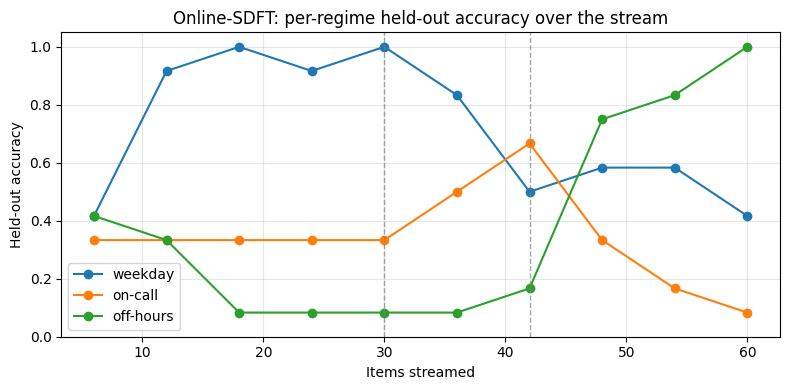

In [8]:
# Three held-out probes collected during the loop (curve[1..3] at each checkpoint).
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
for p, name in enumerate(REGIMES, start=1):
    ax.plot(curve["pos"], curve[p], "-o", label=name)
for x in DRIFTS:
    ax.axvline(x, color="gray", ls="--", lw=1, alpha=0.7)
ax.set_xlabel("Items streamed")
ax.set_ylabel("Held-out accuracy")
ax.set_ylim(0, 1.05)
ax.set_title("Online-SDFT: per-regime held-out accuracy over the stream")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## The figure: one adapter vs frozen context

A short Colab-friendly comparison (not the multi-panel blog figure):

- **Left** — whole-week accuracy (each regime scored *while live*) vs tokens per query.
- **Right** — accumulated regret on streamed items (lower is better).

Online-SDFT should sit near the bare-prompt token cost with competitive live accuracy and lower final regret than ICL/RAG.



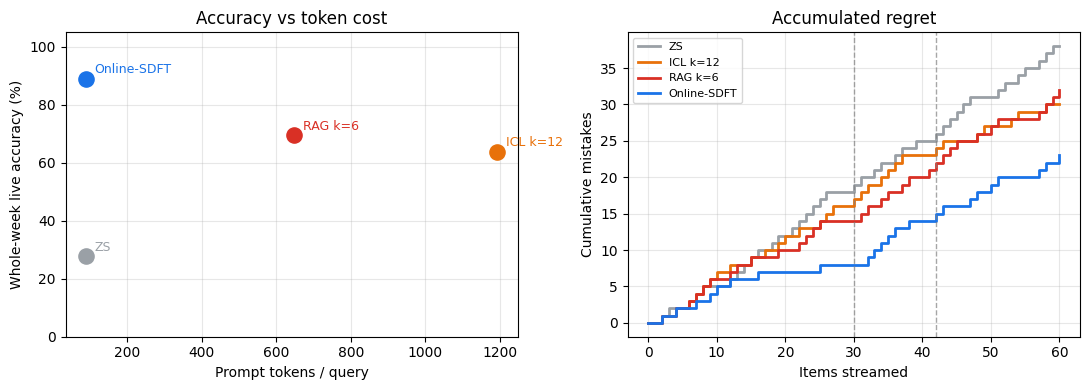

In [9]:
import matplotlib.pyplot as plt

colors = {"ZS": "#9aa0a6", "ICL": "#e8710a", "RAG": "#d93025", "Online-SDFT": "#1a73e8"}

def col(n):
    for k, c in colors.items():
        if n.startswith(k):
            return c
    return "#5f6368"

fig, (ax_acc, ax_reg) = plt.subplots(1, 2, figsize=(11, 4))

for n, d in arms.items():
    ax_acc.scatter(d["tok"], d["mean_live"] * 100, s=120, color=col(n), zorder=3)
    ax_acc.annotate(n, (d["tok"], d["mean_live"] * 100), textcoords="offset points",
                    xytext=(6, 4), fontsize=9, color=col(n))
ax_acc.set_xlabel("Prompt tokens / query")
ax_acc.set_ylabel("Whole-week live accuracy (%)")
ax_acc.set_ylim(0, 105)
ax_acc.set_title("Accuracy vs token cost")
ax_acc.grid(alpha=0.3)

for key, name in (("ZS", "ZS"), ("ICL", f"ICL k={ICL_K}"),
                  ("RAG", f"RAG k={RAG_K}"), ("SDFT", "Online-SDFT")):
    c = colors["Online-SDFT" if key == "SDFT" else key]
    ax_reg.plot(regret["pos"], regret[key], drawstyle="steps-post",
                color=c, lw=2, label=name)
for x in DRIFTS:
    ax_reg.axvline(x, color="gray", ls="--", lw=1, alpha=0.7)
ax_reg.set_xlabel("Items streamed")
ax_reg.set_ylabel("Cumulative mistakes")
ax_reg.set_title("Accumulated regret")
ax_reg.legend(fontsize=8)
ax_reg.grid(alpha=0.3)

fig.tight_layout()
plt.show()


## One item, four ways

Same off-hours **social** notification, graded four ways: zero-shot, ICL, RAG, and
the served Online-SDFT adapter. Off the clock the label flips to **INTERRUPT**
("friends' posts DO deserve a buzz on Saturday"); the base model often files
everything as `LATER`.

We prefer a held-out item where ZS is wrong and Online-SDFT is right (fallback:
first off-hours social). Watch for: ZS/RAG wrong or token-heavy ICL right;
Online-SDFT correct on the bare prompt.


In [15]:
eval_cur[0]

{'subject': 'Starts in 20 min: 1:1 with Priya',
 'snippet': 'Reminder: your meeting with Priya begins soon.',
 'category': 'calendar_soon',
 'phase': 3,
 'action': 'LATER',
 'prompt': 'Triage this inbox item into one of INTERRUPT (buzz the user now), LATER (hold it for the digest), or ARCHIVE (never surface it). Answer with exactly one of INTERRUPT, LATER, or ARCHIVE.\n\nSubject: Starts in 20 min: 1:1 with Priya\nReminder: your meeting with Priya begins soon.'}

In [32]:
# Showcase pick
i = 7
q = evals[3][i] # 1: workday, 2: on-call, 3: off-hours
for k, v in q.items():
  print(f"{k}: {v}")

sdft_gen = generate(model, tok, [q], lambda x: build_msgs(x), bs=8)[0]
with model.disable_adapter():
    zs_gen = generate(model, tok, [q], lambda x: build_msgs(x), bs=8)[0]

# ICL / RAG use the frozen base; ZS / Online-SDFT reuse the batched replies above
with model.disable_adapter():
    icl_g = generate(model, tok, [q],
                     lambda x: build_msgs(x, recent_demos(stream, ICL_K)), bs=1)[0]
    rag_g = generate(model, tok, [q],
                     lambda x: build_msgs(x, retrieve(q, RAG_K)), bs=1)[0]


icl_extra = arms[f"ICL k={ICL_K}"]["tok"] - arms["ZS"]["tok"]
rag_extra = arms[f"RAG k={RAG_K}"]["tok"] - arms["ZS"]["tok"]
answers = [
    ("ZS", parse_action(zs_gen), "bare prompt"),
    (f"ICL k={ICL_K}", parse_action(icl_g), f"+{icl_extra:.0f} tokens every call"),
    (f"RAG k={RAG_K}", parse_action(rag_g), f"+{rag_extra:.0f} tokens every call"),
    ("Online-SDFT", parse_action(sdft_gen), "bare prompt + served adapter"),
]
for name, pred, note in answers:
    mark = "✓" if pred == q["action"] else "✗"
    print(f"  {name:12s} -> {pred:9s} {mark}   ({note})")


subject: [ALERT] a pager alert
snippet: Automated alert: a pager alert detected in production.
category: monitoring
phase: 3
action: ARCHIVE
prompt: Triage this inbox item into one of INTERRUPT (buzz the user now), LATER (hold it for the digest), or ARCHIVE (never surface it). Answer with exactly one of INTERRUPT, LATER, or ARCHIVE.

Subject: [ALERT] a pager alert
Automated alert: a pager alert detected in production.
  ZS           -> INTERRUPT ✗   (bare prompt)
  ICL k=12     -> ARCHIVE   ✓   (+1104 tokens every call)
  RAG k=6      -> ARCHIVE   ✓   (+558 tokens every call)
  Online-SDFT  -> ARCHIVE   ✓   (bare prompt + served adapter)


## What to try next

1. **Change the policy (or make regimes longer)** — edit
   [`triage_common.py`](https://github.com/lin826/Online-SDFT-Demo/blob/main/triage_common.py)
   (`POLICY` / phase specs), re-run `run_baselines.py` to re-export
   `data/inbox_triage.json`, and point `DATA_URL` at your fork.
2. **Noisier feedback** — flip a fraction of observed actions before training, then
   watch the guardrail earn its keep.
3. **Try other ICL/RAG *k*** — the local scripts consider *k* ∈ {3, 6, 9, 12}
   (widen it). On Colab, try other `ICL_K` / `RAG_K` values. Does RAG ever stop
   serving stale weekday answers?
4. **Bigger model** — swap `MODEL_NAME` to `LiquidAI/LFM2.5-1.2B-Instruct`. 3-way
   routing is much steadier with more capacity (needs more VRAM / a longer runtime).
5. **Full toolkit** — [Local-SDFT](https://github.com/lin826/Local-SDFT): the
   `sdft.online` serve-while-learning package (probe guardrail + auto-rollback),
   the `/data` live chat loop, and GRPO.

3-way on a 230M is at the edge — that's the fun. Curiosity, not VRAM, is the bottleneck.
